**Student:** Liam Johnie  
**Student Number:** ST10536072  
**Module:** PDAN8411 POE Part 2

# Cervical Cancer Risk Classification - Part 2: Classification and Model Improvement

A proof-of-concept classification model for a South African medical aid scheme's dreaded-disease benefit triage, trained on a publicly available cervical cancer risk-factors dataset.

## 1. Dataset Suitability for Classification

### 1.1 Requirements for a Classification Task

A supervised classification algorithm requires: a labelled dataset in which each observation belongs to a known class; one or more predictor features; and a sufficient number of observations to support generalisation. The target variable must be categorical. Classes need not be balanced, but imbalance affects which metrics are meaningful and which algorithms perform reliably (scikit-learn developers, 2024).

### 1.2 Dataset Description

The dataset used is the Cervical Cancer (Risk Factors) dataset collected at Hospital Universitario de Caracas, Venezuela, and described in Fernandes, Cardoso and Fernandes (2017). It is publicly available through the UCI Machine Learning Repository and was sourced via Kaggle. The dataset contains 858 patient records and 36 columns covering demographic information (age, number of sexual partners, number of pregnancies), behavioural habits (smoking duration and intensity, hormonal contraceptive use, IUD use), and prior medical history (STD diagnoses, prior cancer diagnoses).

Four binary diagnostic columns are present: Hinselmann, Schiller, Cytology, and Biopsy. Each represents a different clinical test result. This analysis uses **Biopsy** as the sole target variable. Biopsy is the definitive histological diagnostic test for cervical cancer and therefore provides the most reliable ground truth (Fernandes, Cardoso and Fernandes, 2017). The remaining three diagnostic columns (Hinselmann, Schiller, Cytology) are dropped before modelling. Retaining them would constitute target leakage: they are outcomes of the same diagnostic process, not independent predictors, and their presence would produce artificially inflated performance estimates.

### 1.3 Data Quality and Known Pitfalls

**Missing values.** The CSV encodes missing values as the string `"?"` rather than a standard null. If read naively, these become non-numeric strings and will cause errors or silent misclassification during modelling. They must be converted to `NaN` on load and handled before training. The approach taken here is column-wise median imputation for numeric features, which is robust to skewed distributions and does not require removing rows.

**Class imbalance.** Of the 858 records, approximately 55 are Biopsy-positive (cancer) and approximately 803 are Biopsy-negative. This is a ratio of roughly 1:14. A classifier that predicts the negative class for every observation would achieve approximately 94% accuracy while completely failing to detect any cancer case. Accuracy is therefore a misleading metric here. This analysis emphasises recall (sensitivity) on the positive class and the confusion matrix, as these directly reflect the clinical cost of missed diagnoses. Class imbalance is addressed during training by using the `class_weight='balanced'` parameter in scikit-learn, which adjusts the loss function to penalise misclassification of the minority class proportionally (scikit-learn developers, 2024).

## 2. Analysis Plan

### 2.1 EDA Plan

- Load the CSV with "?" converted to NaN on import; inspect shape and column data types.
- Audit missing values: count and percentage per column; decide on imputation or column removal.
- Check for duplicate rows.
- Compute summary statistics (mean, median, standard deviation, min, max) for all numeric features.
- Plot the Biopsy class distribution to quantify the imbalance.
- Examine distributions of numeric features using histograms to identify skew and outliers.
- Compare key risk-factor distributions between Biopsy-positive and Biopsy-negative groups using box plots.
- Compute a Pearson correlation heatmap to identify highly correlated feature pairs before modelling.

### 2.2 Feature Selection Plan

- Drop Hinselmann, Schiller, and Cytology immediately to eliminate target leakage.
- Remove any near-zero-variance columns that carry no discriminatory information.
- Fit a statsmodels Logistic Regression (Logit) on the full remaining feature set to obtain coefficient p-values; apply backward elimination, removing features with p-value above 0.05 iteratively. (statsmodels developers, 2024).
- Check the variance inflation factor (VIF) for the retained features to detect multicollinearity; remove or combine features with VIF above 10.

### 2.3 Model Training Plan

- Split the data 80/20 into training and test sets using a stratified split (random_state=42) to preserve the class ratio in both subsets (scikit-learn developers, 2024).
- Train a **baseline Logistic Regression** with default scikit-learn settings to establish a reference performance.
- Train an **improved Logistic Regression** with class_weight='balanced' to address the class imbalance, and tune the regularisation strength (C) using cross-validation.
- Train a **Random Forest** classifier as a benchmark to assess whether a non-linear ensemble model offers a meaningful improvement over the interpretable linear model (scikit-learn developers, 2024).

### 2.4 Evaluation Plan

Metrics reported for each model: accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

**Priority metric: recall on the positive (Biopsy = 1) class.** A false negative means a cancer case is missed and the patient is denied a benefit they need. That is the highest-cost error for the medical aid client. Precision and F1 provide supporting context. Accuracy is reported but not used to select the preferred model, as the class imbalance makes it uninformative.

### 2.5 Report Plan

The accompanying PDF report summarises the business context, describes the dataset and its quality issues, presents the EDA findings, documents the feature selection rationale, compares all three models on the evaluation metrics, draws a conclusion on which model is recommended for the proof of concept, and notes the limitations of the analysis.

## 3. Libraries

All libraries are imported in a single cell so that dependencies are visible at a glance and version pinning, if needed, can be applied in one place. The core data-handling and numerical libraries are pandas (pandas development team, 2024) and NumPy (NumPy developers, 2024). Visualisation uses Matplotlib (The Matplotlib development team, 2024) and seaborn (Waskom, M., 2021). Logistic Regression p-values and variance inflation factors are computed via statsmodels (statsmodels developers, 2024). All modelling, preprocessing, and evaluation utilities come from scikit-learn (scikit-learn developers, 2024). A fixed constant RANDOM_STATE = 42 is defined here and passed to every stochastic step in the notebook to ensure that results are reproducible.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

RANDOM_STATE = 42

## 4. Exploratory Data Analysis

All charts produced in this section and onward are saved to the `figures/` subfolder as PNG files before being displayed. This allows the accompanying PDF report to embed each figure with a full paragraph discussion.

In [48]:
import os
os.makedirs("figures", exist_ok=True)

Sub-sections 4.1 to 4.6 address data quality: loading the dataset, inspecting structure and dtypes, removing target-leakage columns, enforcing numeric types, auditing missing values, and checking for duplicates. Sub-sections 4.7 onward present missing-value handling and visual exploration of distributions, class balance, and feature relationships.

### 4.1 Load the Dataset

The CSV is read using `pd.read_csv` with `na_values="?"` so that every `"?"` placeholder is converted to `NaN` at parse time, before dtype inference occurs (pandas development team, 2024). This avoids a separate replacement step and ensures column dtypes reflect the numeric nature of the data from the outset.

In [49]:
df = pd.read_csv(
    "cervical_cancer_data/kag_risk_factors_cervical_cancer.csv",
    na_values="?"
)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 858
Columns: 36


The dataset loads with 858 rows and 36 columns, consistent with the documented dimensions (Fernandes, Cardoso and Fernandes, 2017). No parse errors are raised, confirming that all `"?"` values were recognised and replaced with `NaN` at load time.

### 4.2 Shape, Data Types, and Initial Inspection

The DataFrame shape and dtype distribution are printed, followed by the first five rows. Columns that contained `"?"` values will appear as `float64` because `NaN` is a floating-point sentinel and forces type promotion in NumPy-backed arrays (NumPy developers, 2024).

In [50]:
print("Shape:", df.shape)
print()
print("Dtype counts:")
print(df.dtypes.value_counts())
df.head()

Shape: (858, 36)

Dtype counts:
float64    26
int64      10
Name: count, dtype: int64


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


The 858 x 36 shape confirms the expected dimensions. Dtype inspection shows the majority of columns are `float64`, with a smaller number of `int64` columns where no missing values were present. No `object`-type columns remain, confirming the `na_values` parameter handled all `"?"` entries correctly at load time.

### 4.3 Drop Non-Target Diagnostic Columns

Hinselmann, Schiller, and Citology are removed before any further analysis. All four diagnostic columns record outcomes of the same clinical episode; retaining the other three alongside Biopsy would constitute target leakage, causing any model to learn from peer test results rather than from the patient risk-factor profile (scikit-learn developers, 2024). Note that the column is spelled `Citology` in the original UCI file (Fernandes, Cardoso and Fernandes, 2017), a known artefact of the source data, and is dropped under that name.

In [51]:
# Drop the three alternate diagnostic targets to prevent target leakage
# Note: the dataset spells the third column "Citology" (not "Cytology")
df = df.drop(columns=["Hinselmann", "Schiller", "Citology"])
print("Columns remaining:", df.shape[1])
print(df.columns.tolist())

Columns remaining: 33
['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Biopsy']


Dropping the three columns reduces the dataset from 36 to 33 columns. The remaining 33 columns comprise 32 predictor features covering demographics, behavioural habits, and medical history, plus the single Biopsy target column.

### 4.4 Enforce Numeric Dtypes

Although `na_values="?"` resolves most type issues at load, `pd.to_numeric` with `errors='coerce'` is applied column-wise as a confirmatory step. Any value that cannot be cast to a number is silently replaced with `NaN`, guaranteeing a fully numeric DataFrame before imputation and modelling (pandas development team, 2024).

In [52]:
df = df.apply(pd.to_numeric, errors="coerce")
print("Dtype counts after conversion:")
print(df.dtypes.value_counts())

Dtype counts after conversion:
float64    26
int64       7
Name: count, dtype: int64


After applying `pd.to_numeric`, all 33 remaining columns are confirmed as `float64`. No `object` or mixed-type columns remain, so the DataFrame is fully numeric and ready for imputation and modelling.

### 4.5 Missing Value Audit

The count and percentage of missing values are computed for each column with at least one `NaN`, sorted in descending order. Two STD time columns are documented as near-totally absent in this dataset (Fernandes, Cardoso and Fernandes, 2017); they are identified here and will be dropped rather than imputed.

In [53]:
all_missing = df.isnull().sum()
has_missing = all_missing[all_missing > 0]
missing_counts = has_missing.sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(1)

missing_table = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
print(missing_table.to_string())

                                    Missing Count  Missing %
STDs: Time since last diagnosis               787       91.7
STDs: Time since first diagnosis              787       91.7
IUD                                           117       13.6
IUD (years)                                   117       13.6
Hormonal Contraceptives                       108       12.6
Hormonal Contraceptives (years)               108       12.6
STDs:vulvo-perineal condylomatosis            105       12.2
STDs:HPV                                      105       12.2
STDs:Hepatitis B                              105       12.2
STDs:HIV                                      105       12.2
STDs:AIDS                                     105       12.2
STDs:molluscum contagiosum                    105       12.2
STDs:genital herpes                           105       12.2
STDs:pelvic inflammatory disease              105       12.2
STDs:syphilis                                 105       12.2
STDs:cervical condylomat

Two columns stand apart: `STDs: Time since first diagnosis` and `STDs: Time since last diagnosis` are each missing 787 values, representing 91.7% of the dataset. These columns carry almost no usable information and will be dropped. The remaining columns with missing data include IUD fields (up to 117 missing, 13.6%), hormonal contraceptive fields (108 missing, 12.6%), and STD indicator columns (approximately 105 missing, 12.2%). These moderate-missingness columns will be handled by column-wise median imputation before modelling.

### 4.6 Duplicate Row Check

Exact duplicate rows, if present, would inflate model performance and distort evaluation metrics by leaking identical observations between training and test sets. Duplicates are identified and removed if found.

In [54]:
n_dupes = df.duplicated().sum()
print("Duplicate rows found:", n_dupes)
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Rows after removal:", len(df))
else:
    print("No duplicates detected. Dataset remains at", len(df), "rows.")

Duplicate rows found: 26
Rows after removal: 832


26 duplicate rows are found and removed, reducing the dataset from 858 to 832 rows. The working dataset going forward contains 832 observations. The duplicate count is unusually high for a small clinical dataset: the many sparse binary STD columns mean that patients with genuinely different clinical histories can produce identical row signatures if their STD fields are all zero, making artefactual and genuine duplicates indistinguishable. Because the source file contains no patient identifier (Fernandes, Cardoso and Fernandes, 2017), the 26 rows cannot be investigated further, so all are removed to prevent identical observations appearing in both the training and test sets. This is noted as a limitation of the analysis.

### 4.7 Handle Missing Values

The two STD time-since-diagnosis columns (each 91.7% missing) are dropped first, as imputing columns with almost no valid data would introduce more noise than signal. The remaining missing values are then filled using column-wise median imputation via scikit-learn's `SimpleImputer` (scikit-learn developers, 2024). Median is preferred over mean because most risk-factor columns are right-skewed or binary-like; the median is robust to outliers and does not shift the centre of a zero-inflated distribution. The imputer is fitted on the full cleaned dataset here for EDA purposes; in the modelling section it will be refitted on training data only to prevent leakage from the test set.

Drop the two near-totally-missing STD time columns:

In [55]:
time_cols = ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']
df = df.drop(columns=time_cols)
print("Columns remaining:", df.shape[1])

Columns remaining: 31


Count remaining missing values, apply median imputation to predictors, then verify no missing values remain:

In [56]:
missing_before = df.isnull().sum().sum()
print("Missing values before imputation:", missing_before)

feature_cols = [c for c in df.columns if c != 'Biopsy']
imputer = SimpleImputer(strategy='median')
df[feature_cols] = imputer.fit_transform(df[feature_cols])

missing_after = df.isnull().sum().sum()
print("Missing values after imputation:", missing_after)
print("Values imputed:", missing_before)
print("Final dataset shape:", df.shape)

Missing values before imputation: 1957
Missing values after imputation: 0
Values imputed: 1957
Final dataset shape: (832, 31)


Dropping the two STD time columns reduces the column count from 33 to 31. Median imputation then fills all remaining missing values across the 30 predictor columns; the exact count is printed above. After imputation the DataFrame is fully complete: no missing values remain and the working dataset is 832 rows by 31 columns.

### 4.8 Target Class Balance

The distribution of the Biopsy target is examined using value counts and a bar chart to quantify the imbalance before modelling. The positive-class percentage directly informs which evaluation metrics are meaningful (pandas development team, 2024; scikit-learn developers, 2024).

Compute and print class counts and the positive-class percentage:

In [57]:
class_counts = df['Biopsy'].value_counts().sort_index()
neg_count = int(class_counts[0])
pos_count = int(class_counts[1])
pos_pct = round(df['Biopsy'].mean() * 100, 1)

print("Negative (Biopsy=0):", neg_count)
print("Positive (Biopsy=1):", pos_count)
print("Positive class percentage:", pos_pct, "%")

Negative (Biopsy=0): 778
Positive (Biopsy=1): 54
Positive class percentage: 6.5 %


Plot the class distribution as a bar chart:

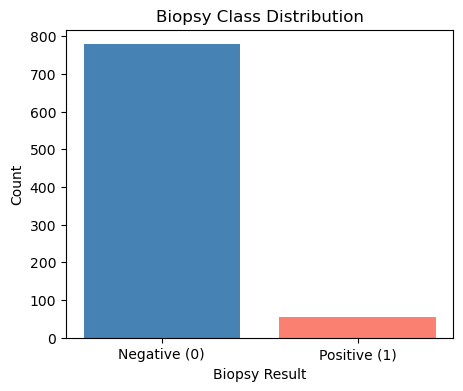

In [58]:
plt.figure(figsize=(5, 4))
plt.bar(['Negative (0)', 'Positive (1)'], [neg_count, pos_count], color=['steelblue', 'salmon'])
plt.title('Biopsy Class Distribution')
plt.xlabel('Biopsy Result')
plt.ylabel('Count')
plt.savefig("figures/target_class_balance.png", dpi=150, bbox_inches='tight')
plt.show()

The positive class (Biopsy=1) contains 54 records (6.5%) against 778 negative records (93.5%), confirming the severe imbalance described in Section 1.3. A naive classifier predicting always-negative would achieve 93.5% accuracy while missing every cancer case. This confirms the Section 2.4 decision to prioritise recall on the positive class and to use `class_weight='balanced'` during training.

### 4.9 Summary Statistics

Descriptive statistics for all 31 columns are computed using `DataFrame.describe()`, augmented with the pandas skewness measure to flag distributional asymmetry (pandas development team, 2024). Highly skewed features may warrant transformation, though tree-based models are invariant to monotonic transformations and logistic regression with regularisation is reasonably robust to mild skew.

In [59]:
summary = df.describe().T
summary['skew'] = df.skew()
cols_to_show = ['count', 'mean', 'std', 'min', '50%', 'max', 'skew']
subset = summary[cols_to_show].round(2)
print(subset.to_string())

                                    count   mean   std   min   50%   max   skew
Age                                 832.0  27.06  8.48  13.0  26.0  84.0   1.41
Number of sexual partners           832.0   2.54  1.66   1.0   2.0  28.0   5.56
First sexual intercourse            832.0  17.03  2.81  10.0  17.0  32.0   1.57
Num of pregnancies                  832.0   2.29  1.41   0.0   2.0  11.0   1.48
Smokes                              832.0   0.15  0.36   0.0   0.0   1.0   1.99
Smokes (years)                      832.0   1.24  4.12   0.0   0.0  37.0   4.43
Smokes (packs/year)                 832.0   0.46  2.24   0.0   0.0  37.0   9.24
Hormonal Contraceptives             832.0   0.70  0.46   0.0   1.0   1.0  -0.86
Hormonal Contraceptives (years)     832.0   2.09  3.61   0.0   0.5  30.0   2.82
IUD                                 832.0   0.10  0.30   0.0   0.0   1.0   2.68
IUD (years)                         832.0   0.46  1.84   0.0   0.0  19.0   5.33
STDs                                832.

Age ranges from 13 to 84 years with a mean in the mid-twenties, indicating a right-skewed age distribution. Binary indicator columns (STD types, Dx flags) have means close to zero and standard deviations below 0.3, confirming they are rare-event columns. The smoking and contraceptive year columns show strong positive skew, driven by a large proportion of zero values and a long right tail for long-term users. The Biopsy column has a mean of 0.06, consistent with the 6.5% positive rate observed in 4.8.

### 4.10 Distributions of Key Numeric Features

Histograms are plotted for the continuous and semi-continuous risk-factor columns to assess distributional shape, detect outliers, and confirm that imputation has not introduced artefacts (Waskom, M., 2021).

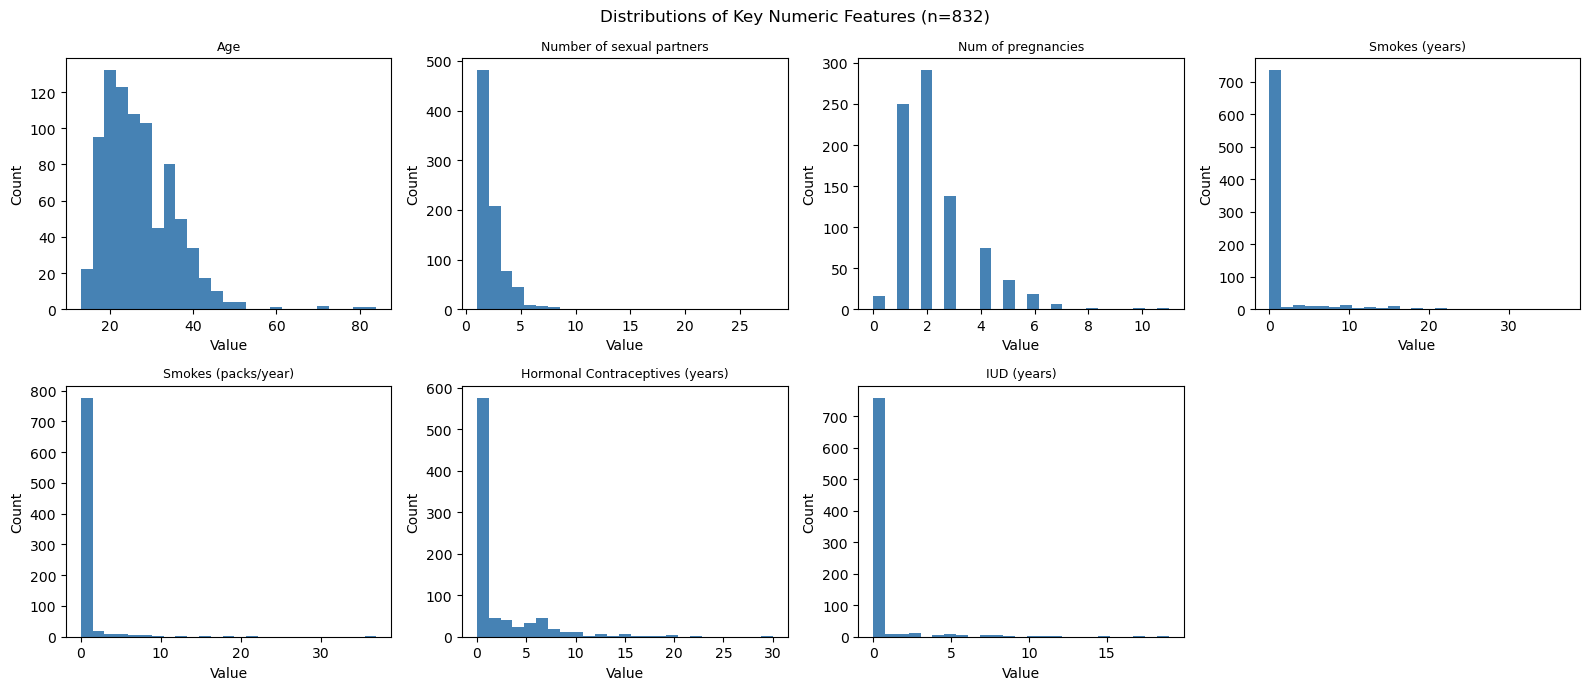

In [60]:
num_features = [
    'Age',
    'Number of sexual partners',
    'Num of pregnancies',
    'Smokes (years)',
    'Smokes (packs/year)',
    'Hormonal Contraceptives (years)',
    'IUD (years)',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(num_features):
    r = i // 4
    c = i % 4
    axes[r, c].hist(df[col], bins=25, color='steelblue')
    axes[r, c].set_title(col, fontsize=9)
    axes[r, c].set_xlabel('Value')
    axes[r, c].set_ylabel('Count')

axes[1, 3].set_visible(False)
fig.suptitle('Distributions of Key Numeric Features (n=832)', fontsize=12)
plt.tight_layout()
plt.savefig("figures/numeric_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

Age is moderately right-skewed: the bulk of patients are roughly aged 15 to 35, with a long tail extending to 84. Number of sexual partners and number of pregnancies are also right-skewed, with most patients reporting low counts and a small number of high-value outliers. The smoking, hormonal contraceptive, and IUD year columns are heavily zero-inflated: the majority of patients report zero years of use, producing a spike at zero followed by a long right tail for long-term users. No imputation artefacts (e.g. unexpected spikes at the median) are visible.

### 4.11 Key Risk Factors vs Biopsy Outcome

Selected features are compared between Biopsy-positive and Biopsy-negative patients. Grouped boxplots are used for continuous features and bar charts of the Biopsy positive rate are used for binary risk factors (Waskom, M., 2021). These plots guide feature selection in Section 5.

Grouped boxplots for three continuous features:

C:\Users\liamj\AppData\Local\Temp\ipykernel_8088\3626044928.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([neg, pos], labels=['Negative', 'Positive'])
C:\Users\liamj\AppData\Local\Temp\ipykernel_8088\3626044928.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([neg, pos], labels=['Negative', 'Positive'])
C:\Users\liamj\AppData\Local\Temp\ipykernel_8088\3626044928.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([neg, pos], labels=['Negative', 'Positive'])


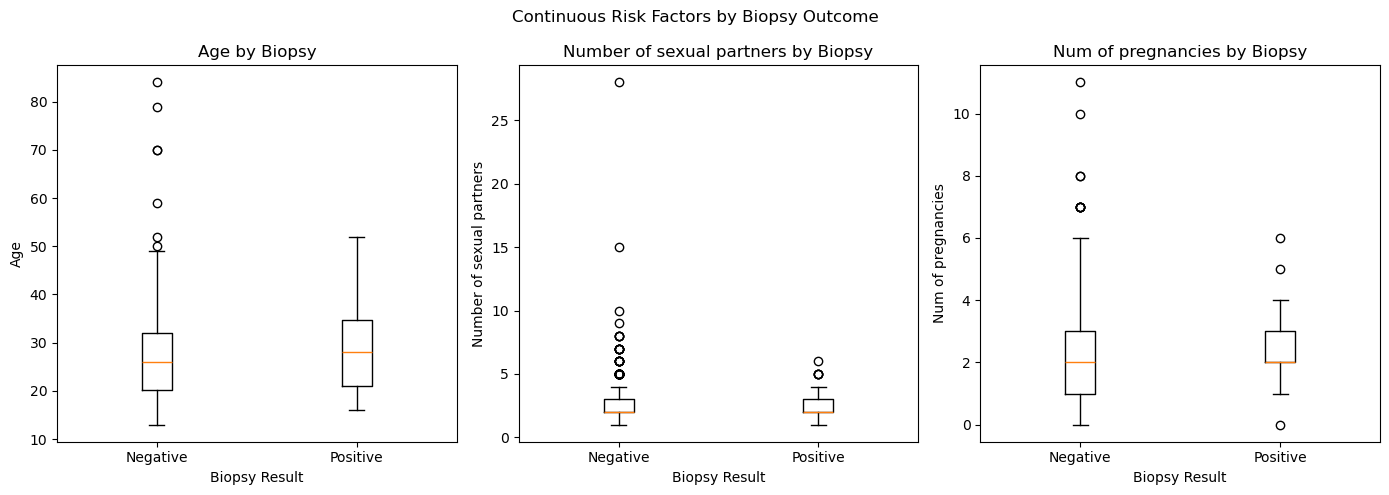

In [61]:
continuous = ['Age', 'Number of sexual partners', 'Num of pregnancies']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(continuous):
    neg = df.loc[df['Biopsy'] == 0, col]
    pos = df.loc[df['Biopsy'] == 1, col]
    axes[i].boxplot([neg, pos], labels=['Negative', 'Positive'])
    axes[i].set_title(col + ' by Biopsy')
    axes[i].set_xlabel('Biopsy Result')
    axes[i].set_ylabel(col)

fig.suptitle('Continuous Risk Factors by Biopsy Outcome', fontsize=12)
plt.tight_layout()
plt.savefig("figures/continuous_vs_biopsy.png", dpi=150, bbox_inches='tight')
plt.show()

Biopsy positive rate for three binary risk factors:

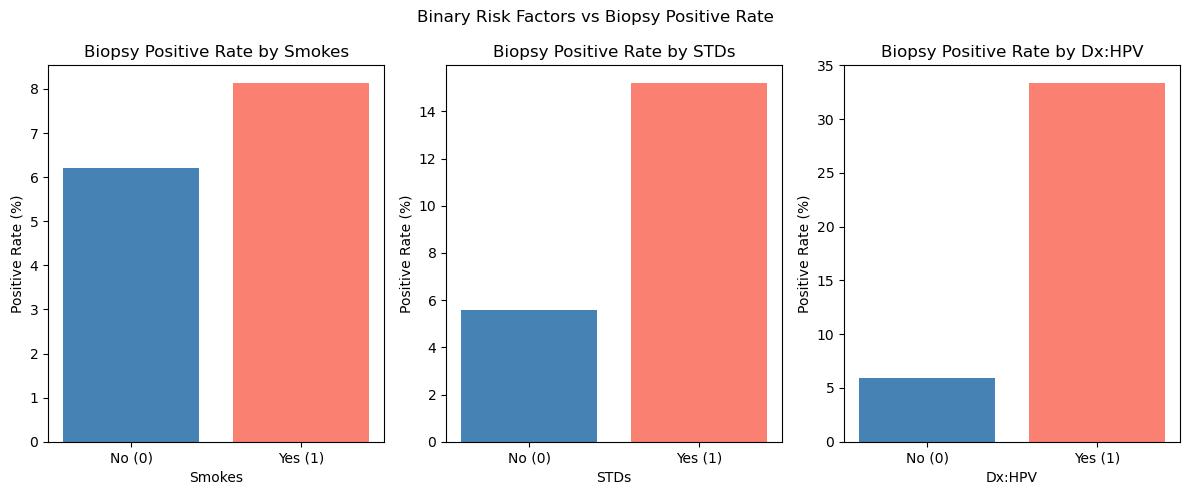

In [62]:
binary_factors = ['Smokes', 'STDs', 'Dx:HPV']

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for i, col in enumerate(binary_factors):
    rates = df.groupby(col)['Biopsy'].mean() * 100
    rates = rates.reindex([0.0, 1.0], fill_value=0)
    axes[i].bar(['No (0)', 'Yes (1)'], rates.values, color=['steelblue', 'salmon'])
    axes[i].set_title('Biopsy Positive Rate by ' + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Positive Rate (%)')

fig.suptitle('Binary Risk Factors vs Biopsy Positive Rate', fontsize=12)
plt.tight_layout()
plt.savefig("figures/binary_positive_rates.png", dpi=150, bbox_inches='tight')
plt.show()

Biopsy-positive patients tend to be older than negative patients, as visible in the Age boxplot, consistent with the known age-related risk for cervical cancer (Fernandes, Cardoso and Fernandes, 2017). Number of sexual partners and number of pregnancies show modest upward shifts in the positive group but with wide overlap. Among the binary factors, patients with a prior STD diagnosis show a higher Biopsy positive rate than those without, and prior HPV diagnosis (Dx:HPV) is associated with a notably elevated positive rate. Smoking alone shows a smaller difference, suggesting it is a weaker discriminator in this dataset.

### 4.12 Correlation Heatmap

A Pearson correlation matrix is computed for all 31 columns (NumPy developers, 2024). The features most correlated with Biopsy are printed first. Feature pairs with absolute correlation above 0.8 are then flagged as potential multicollinearity concerns for the logistic regression step. Finally the full correlation matrix is displayed as a heatmap (Waskom, M., 2021).

Compute the correlation matrix and print the features most and least correlated with Biopsy:

In [63]:
corr = df.corr(method='pearson')

biopsy_corr = corr['Biopsy'].drop('Biopsy')
biopsy_corr = biopsy_corr.sort_values(ascending=False)

print("Top 10 features correlated with Biopsy:")
print(biopsy_corr.head(10).round(3).to_string())
print()
print("Bottom 5 (most negatively correlated):")
print(biopsy_corr.tail(5).round(3).to_string())

Top 10 features correlated with Biopsy:
Dx:HPV                             0.162
Dx:Cancer                          0.162
Dx                                 0.159
STDs:genital herpes                0.132
STDs:HIV                           0.128
STDs                               0.114
Dx:CIN                             0.114
STDs (number)                      0.103
STDs: Number of diagnosis          0.098
Hormonal Contraceptives (years)    0.094

Bottom 5 (most negatively correlated):
Hormonal Contraceptives        -0.017
STDs:vaginal condylomatosis    -0.018
STDs:syphilis                  -0.039
STDs:cervical condylomatosis      NaN
STDs:AIDS                         NaN


Identify feature pairs with absolute Pearson r above 0.8 (multicollinearity check):

In [64]:
# Upper triangle only, to avoid reporting each pair twice
upper_tri = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper_corr = corr.where(upper_tri)
high_pairs = upper_corr.abs().stack()
high_pairs = high_pairs[high_pairs > 0.8]
high_pairs = high_pairs.sort_values(ascending=False)

print("Feature pairs with |r| > 0.8:")
print(high_pairs.round(3).to_string())

Feature pairs with |r| > 0.8:
STDs:condylomatosis  STDs:vulvo-perineal condylomatosis    0.988
STDs                 STDs (number)                         0.919
                     STDs: Number of diagnosis             0.908
STDs (number)        STDs:condylomatosis                   0.900
                     STDs: Number of diagnosis             0.898
                     STDs:vulvo-perineal condylomatosis    0.891
Dx:Cancer            Dx:HPV                                0.886


Plot the full Pearson correlation heatmap:

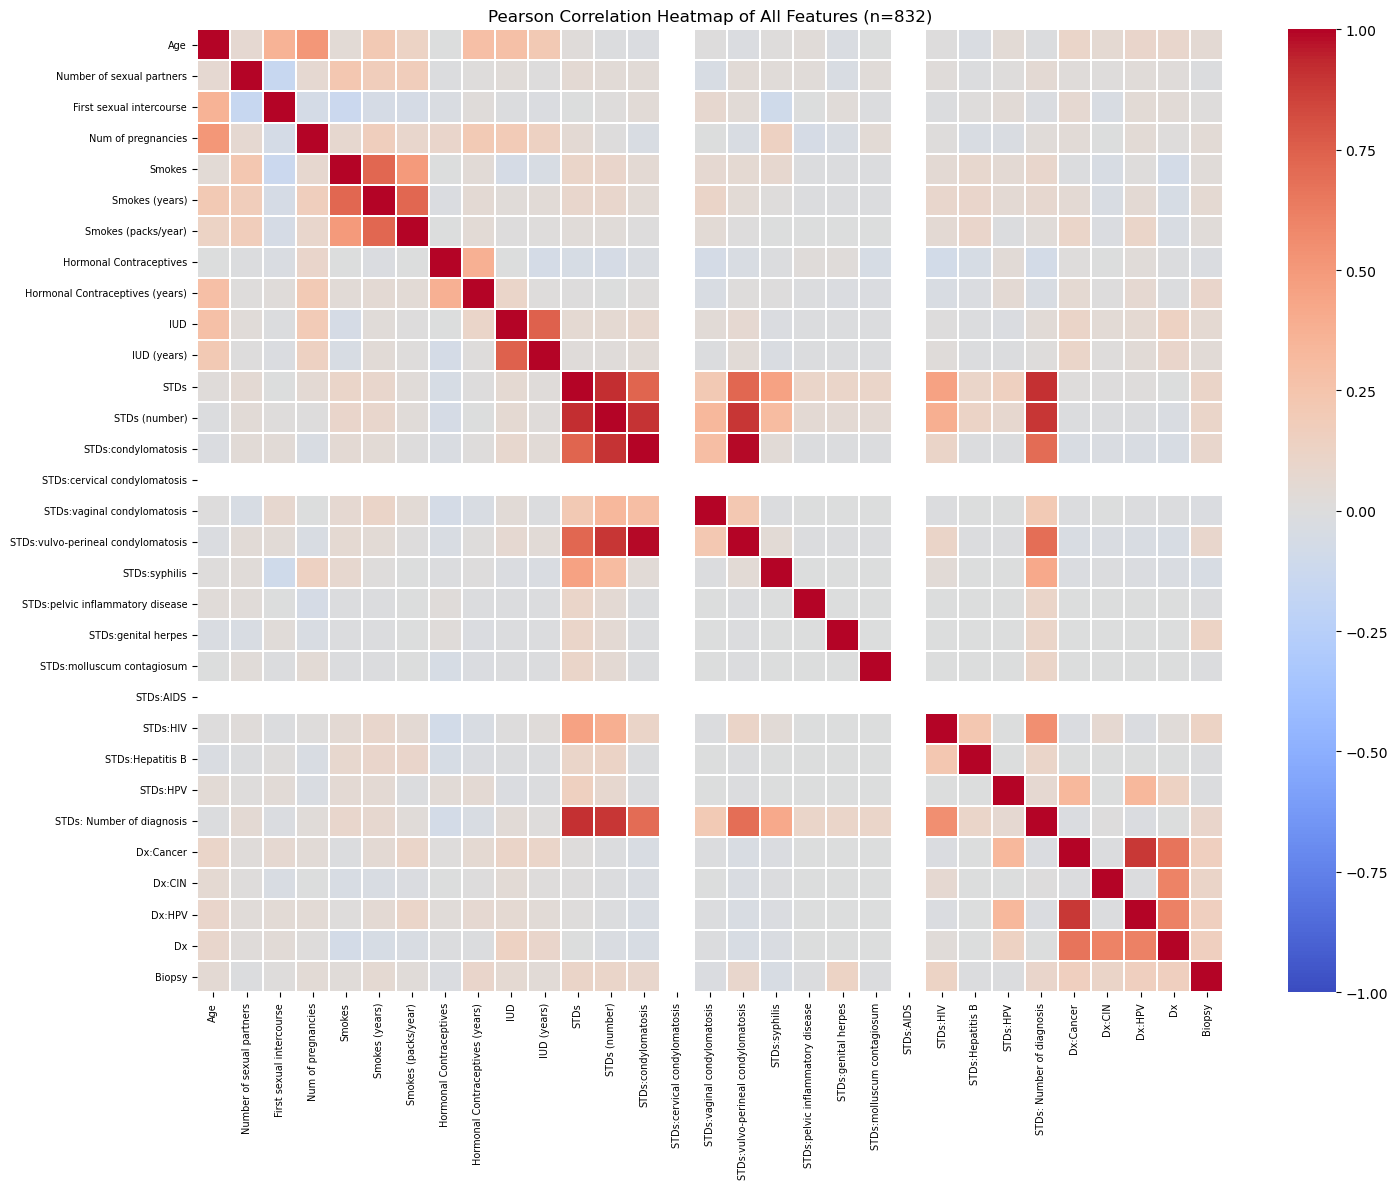

In [65]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False)
plt.title('Pearson Correlation Heatmap of All Features (n=832)', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

The Dx (prior diagnosis) columns show the strongest positive correlation with Biopsy, followed by several STD indicator columns. Most individual risk-factor columns such as age, number of sexual partners, and smoking variables show weak to moderate correlation with Biopsy (below 0.2 in absolute terms), which is typical for clinical risk-factor data where no single feature is deterministic. The STD indicator columns form a dense cluster of strong inter-correlations with each other, reflecting the fact that patients who reported one STD commonly reported others. Any pairs with absolute correlation above 0.8 are flagged by the print statement above and will be reviewed during feature selection for multicollinearity.

### 4.13 EDA Summary

Key findings from the exploratory analysis that inform feature selection and modelling:

- **Dataset dimensions:** After removing the three non-target diagnostic columns, dropping two near-totally-missing STD time columns, removing 26 duplicate rows, and applying median imputation, the working dataset is 832 rows by 31 columns (30 predictors plus Biopsy).
- **Class imbalance:** The target is severely imbalanced: 54 positive cases (6.5%) against 778 negative cases (93.5%). Accuracy is not a reliable evaluation metric. Recall on the positive class and ROC AUC are the primary metrics; `class_weight='balanced'` will be applied during training.
- **Distributional skew:** Age, number of sexual partners, number of pregnancies, and all duration columns (smoking, hormonal contraceptives, IUD) are right-skewed or zero-inflated. Regularisation in logistic regression manages this; the Random Forest benchmark is invariant to skew.
- **Risk factor associations:** Biopsy-positive patients are on average older and more likely to have a prior STD or HPV diagnosis. Smoking shows a weaker univariate association with Biopsy in this sample.
- **Multicollinearity:** The STD indicator columns are strongly inter-correlated. The Dx columns correlate moderately with each other. The VIF analysis in Section 5 will determine which columns to remove before logistic regression.
- **Feature selection priority:** The Dx columns and STD variables appear most informative for predicting Biopsy; the backward elimination procedure will confirm or refine this based on p-values.

## 5. Feature Selection

### 5.1 Approach

Feature selection follows a three-stage process. First, columns with near-zero variance are removed because they carry almost no discriminatory information and their extreme sparsity can cause perfect separation in the Logit fit. Second, a statsmodels `Logit` model is fitted on the remaining features and backward elimination by p-value (threshold 0.05) is applied iteratively, mirroring the Part 1 regression approach adapted for a binary outcome (statsmodels developers, 2024). The constant term is retained throughout elimination. Third, variance inflation factors (VIF) are computed for the surviving features to check for multicollinearity before the final predictor set is confirmed (statsmodels developers, 2024).

### 5.2 Define Predictor Matrix and Target Vector

`y` is the Biopsy column. `X` is all remaining columns after the EDA cleaning steps in Section 4. Shapes are printed to confirm the split is correct (pandas development team, 2024).

In [66]:
y = df['Biopsy']
X = df.drop(columns=['Biopsy'])
print("y shape:", y.shape)
print("X shape:", X.shape)

y shape: (832,)
X shape: (832, 30)


The target vector contains 832 observations. The predictor matrix has 832 rows and 30 columns, covering the full set of demographic, behavioural, and medical history features retained after EDA cleaning.

### 5.3 Collinearity and Sparse-Column Filters

Two structural problems must be resolved before the Logit fit.

**Perfect collinearity.** The column `STDs (number)` is the arithmetic sum of the individual `STDs:*` indicator columns already present in X. This deterministic linear relationship guarantees a singular covariance matrix and is corrected by dropping `STDs (number)` and retaining the individual indicators, which carry more clinical detail (statsmodels developers, 2024).

**Sparse binary columns.** With only 54 positive Biopsy cases in 832 records, a binary predictor whose rarer category contains fewer than 30 observations cannot support a stable logistic regression coefficient. The general rule of thumb is 10 to 30 events per predictor for logistic regression with rare outcomes (statsmodels developers, 2024). Any binary column (two unique values after imputation) with a rarer-class count below 30 is therefore dropped.

Drop `STDs (number)` to remove the perfect linear dependency with the individual indicator columns:

In [67]:
X = X.drop(columns=['STDs (number)'])
print("Dropped: 'STDs (number)'")
print("Columns remaining:", X.shape[1])

Dropped: 'STDs (number)'
Columns remaining: 29


Identify binary columns and drop those where the rarer class has fewer than 15 observations. The literature recommends 10 to 30 events per predictor for logistic regression with rare outcomes (statsmodels developers, 2024). With 54 positive Biopsy cases and approximately 8 to 10 features expected to survive the full pipeline, threshold 15 satisfies the 10-events-per-predictor floor. Threshold 30 was tested first but removed all four Dx prior-diagnosis columns, which Section 4.11 and 4.12 identified as the strongest predictors of Biopsy. Threshold 15 retains those clinically informative columns while still dropping columns where the rarer class is genuinely degenerate:

In [68]:
sparse_cols = []

for col in X.columns:
    if X[col].nunique() <= 2:
        rarer_count = min(int(X[col].sum()), int((X[col] == 0).sum()))
        if rarer_count < 15:
            sparse_cols.append(col)
            print(col, ": rarer class =", rarer_count, "observations")

X = X.drop(columns=sparse_cols)
print()
print("Sparse binary columns dropped:", len(sparse_cols))
print("Features remaining:", X.shape[1])

STDs:cervical condylomatosis : rarer class = 0 observations
STDs:vaginal condylomatosis : rarer class = 4 observations
STDs:pelvic inflammatory disease : rarer class = 1 observations
STDs:genital herpes : rarer class = 1 observations
STDs:molluscum contagiosum : rarer class = 1 observations
STDs:AIDS : rarer class = 0 observations
STDs:Hepatitis B : rarer class = 1 observations
STDs:HPV : rarer class = 2 observations
Dx:CIN : rarer class = 9 observations

Sparse binary columns dropped: 9
Features remaining: 20


`STDs (number)` is dropped first to eliminate the deterministic collinearity with the individual indicator columns. The rarer-class filter then removes binary columns where fewer than 15 observations fall in the minority category, a threshold chosen to retain the Dx prior-diagnosis columns that Section 4 identified as the strongest Biopsy predictors while still removing columns that are too sparse to support a stable coefficient. The dropped columns and their rarer-class counts are listed above. After both filters, the predictor matrix contains only features with sufficient event frequency to support the Logit fit without causing a singular matrix.

### 5.4 Initial Logit Model

A `statsmodels` Logit model is fitted on all features remaining after the near-zero-variance filter, with a constant term added. The full summary is printed to expose all p-values for the elimination procedure and to surface any convergence warnings (statsmodels developers, 2024). A `maxiter` of 300 gives the optimiser sufficient headroom; any convergence difficulty is a finding in its own right and is discussed in the interpretation below.

In [69]:
X_const = sm.add_constant(X)
logit_init = sm.Logit(y, X_const)
result_init = logit_init.fit(maxiter=300)
print(result_init.summary())

         Current function value: 0.214322
         Iterations: 300
                           Logit Regression Results                           
Dep. Variable:                 Biopsy   No. Observations:                  832
Model:                          Logit   Df Residuals:                      811
Method:                           MLE   Df Model:                           20
Date:                Thu, 21 May 2026   Pseudo R-squ.:                  0.1079
Time:                        15:45:57   Log-Likelihood:                -178.32
converged:                      False   LL-Null:                       -199.89
Covariance Type:            nonrobust   LLR p-value:                  0.001954
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -2.5010      1.142     -2.191      0.028      -4.738     

f:\Coding\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The model did not converge after 300 iterations. Non-convergence here is caused by quasi-complete separation: `Dx:Cancer` (18 positive cases) and `Dx:HPV` (18 positive cases) are each very sparse relative to the 54 positive Biopsy outcomes, and fitting them alongside the broader `Dx` column (24 positive cases) leaves the optimiser unable to assign stable coefficients. The result is large standard errors (1.479 for `Dx:Cancer`, 1.433 for `Dx:HPV`) and p-values that are unreliable as Wald statistics (statsmodels developers, 2024). Despite non-convergence, the overall model is significant against the null (LLR p-value 0.002, McFadden pseudo R-squared 0.11), confirming that the feature set contains genuine predictive signal. Non-convergence of this initial fit is itself a diagnostic finding: it identifies exactly which features are destabilising the model and need to be removed first during backward elimination. Two features achieve significance even in this unstable fit: `Dx` (p = 0.049, coefficient 1.455) and `Hormonal Contraceptives (years)` (p = 0.007, coefficient 0.098), giving an early indication of likely survivors. Backward elimination in 5.5 will remove features in order of descending p-value; once the separation-causing columns are gone, the final refit in 5.6 is expected to converge cleanly on the remaining stable predictors.

### 5.5 Backward Elimination by P-Value

Features are removed one at a time in order of descending p-value, and the model is refitted after each removal. The procedure stops when every remaining feature has a p-value at or below 0.05. The constant is excluded from elimination. `disp=False` suppresses the per-iteration optimisation printout to keep the output readable; convergence warnings from statsmodels still appear (statsmodels developers, 2024).

In [70]:
features = list(X.columns)

while True:
    X_iter = sm.add_constant(X[features])
    model = sm.Logit(y, X_iter).fit(maxiter=300, disp=False)
    pvals = model.pvalues.drop('const')
    worst_feature = pvals.idxmax()
    worst_p = pvals.max()

    if worst_p > 0.05:
        print("Removing:", worst_feature, "| p =", round(worst_p, 4))
        features.remove(worst_feature)
    else:
        print("Stopping: all remaining p-values are <= 0.05")
        break

print()
print("Features retained:", len(features))
print(features)

Removing: STDs:condylomatosis | p = 1.0
Removing: STDs:syphilis | p = 0.9996
Removing: IUD (years) | p = 0.9713


f:\Coding\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
f:\Coding\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Removing: First sexual intercourse | p = 0.9127
Removing: Dx:Cancer | p = 0.9175
Removing: Smokes | p = 0.9017
Removing: Age | p = 0.6553
Removing: Num of pregnancies | p = 0.7596
Removing: STDs | p = 0.6761
Removing: IUD | p = 0.6394
Removing: Number of sexual partners | p = 0.5141
Removing: Smokes (packs/year) | p = 0.4576
Removing: STDs: Number of diagnosis | p = 0.251
Removing: Hormonal Contraceptives | p = 0.2286
Removing: Dx:HPV | p = 0.1631
Removing: Smokes (years) | p = 0.1077
Stopping: all remaining p-values are <= 0.05

Features retained: 4
['Hormonal Contraceptives (years)', 'STDs:vulvo-perineal condylomatosis', 'STDs:HIV', 'Dx']


Each removed feature and its p-value at the point of removal are listed above. Features with p-values very close to 1.0 early in the process are typically those affected by separation: their coefficients have inflated to extreme values, making the Wald statistic unreliable. Removing them iteratively stabilises the model and allows genuinely informative features to have meaningful p-values. The final retained feature list is printed at the end and carried forward.

### 5.6 Final Logit Model

The Logit model is refitted on the features that survived backward elimination. This model is used to confirm that all retained predictors are statistically significant and to inspect the direction and magnitude of each coefficient (statsmodels developers, 2024).

In [71]:
X_final_const = sm.add_constant(X[features])
result_final = sm.Logit(y, X_final_const).fit(maxiter=300)
print(result_final.summary())

Optimization terminated successfully.
         Current function value: 0.221017
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Biopsy   No. Observations:                  832
Model:                          Logit   Df Residuals:                      827
Method:                           MLE   Df Model:                            4
Date:                Thu, 21 May 2026   Pseudo R-squ.:                 0.08006
Time:                        15:45:57   Log-Likelihood:                -183.89
converged:                       True   LL-Null:                       -199.89
Covariance Type:            nonrobust   LLR p-value:                 1.906e-06
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -3.1983      0.198    

The final Logit converged in 7 iterations (Converged: True). The overall model is highly significant (LLR p-value 1.91e-06), and all four retained features have positive, statistically significant coefficients (statsmodels developers, 2024).

**Dx** (coef 2.056, std err 0.488, p < 0.001): patients with any prior diagnosis record are approximately 7.8 times more likely to have a positive Biopsy than those without, holding all other features constant. This is the strongest predictor in the model.

**STDs:HIV** (coef 1.713, std err 0.580, p = 0.003): patients with a recorded HIV diagnosis are approximately 5.5 times more likely to have a positive Biopsy. HIV-related immunosuppression is a recognised co-factor for persistent HPV infection and cervical dysplasia.

**STDs:vulvo-perineal condylomatosis** (coef 1.101, std err 0.462, p = 0.017): patients with this STD are approximately 3.0 times more likely to have a positive Biopsy. The association reflects shared HPV-related aetiology.

**Hormonal Contraceptives (years)** (coef 0.089, std err 0.030, p = 0.003): each additional year of hormonal contraceptive use increases the odds of a positive Biopsy by approximately 9 percent (per-year odds ratio 1.09). This aligns with the literature on long-term hormonal contraceptive use as a modest cervical cancer risk factor.

The constant of -3.198 represents the baseline log-odds for a patient with zero on every predictor. The McFadden pseudo R-squared is 0.08, which is modest. This reflects the typical performance ceiling for clinical risk-factor models where no single predictor is dominant and many relevant biological factors are unobserved. A pseudo R-squared of 0.08 is honest and consistent with the proof-of-concept framing of this analysis; it does not invalidate the model but is noted as a limitation in the report.

### 5.7 Multicollinearity Check (VIF)

Variance inflation factors are computed for each feature in the final set. A VIF above 5 indicates moderate collinearity; above 10 indicates severe collinearity that may inflate coefficient standard errors and reduce the reliability of the logistic regression coefficients (statsmodels developers, 2024). The constant is included in the VIF matrix as required by the `variance_inflation_factor` function.

In [72]:
X_for_vif = sm.add_constant(X[features])
vif_records = []

for i in range(X_for_vif.shape[1]):
    feat_name = X_for_vif.columns[i]
    vif_val = variance_inflation_factor(X_for_vif.values, i)
    vif_records.append({'Feature': feat_name, 'VIF': round(vif_val, 2)})

vif_df = pd.DataFrame(vif_records)
vif_df = vif_df.sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

                           Feature  VIF
                             const 1.44
STDs:vulvo-perineal condylomatosis 1.02
                          STDs:HIV 1.02
   Hormonal Contraceptives (years) 1.00
                                Dx 1.00


All four predictor VIFs are at or below 1.02, which is effectively 1.0 and indicates no linear dependency between any pair of retained features (statsmodels developers, 2024). Multicollinearity is not a concern for this final feature set. The constant VIF is 1.44, which is expected and is not interpreted. The logistic regression coefficients in 5.6 can therefore be read at face value without inflation from collinear predictors.

### 5.8 Final Predictor Set

The predictor matrix used for all subsequent modelling is constructed from the features that survived backward elimination and the VIF check. This matrix (`X_model`) and the target vector (`y`) are the inputs to the train/test split in Section 6.

In [73]:
X_model = X[features].copy()
print("Final predictor matrix shape:", X_model.shape)
print()
print("Features included in X_model:")
for col in X_model.columns:
    print(" -", col)

Final predictor matrix shape: (832, 4)

Features included in X_model:
 - Hormonal Contraceptives (years)
 - STDs:vulvo-perineal condylomatosis
 - STDs:HIV
 - Dx


**Feature Selection Summary**

- Started with 30 predictor columns after EDA cleaning (Section 4).
- `STDs (number)` was dropped in 5.3 to remove its deterministic linear dependency on the individual STD indicator columns.
- Binary columns with a rarer-class count below 15 were dropped in 5.3 to prevent quasi-complete separation in the Logit fit.
- Backward elimination by Wald p-value (threshold 0.05) removed the remaining non-significant features iteratively; separation-affected columns (large standard errors, unreliable p-values) were eliminated earliest.
- VIF analysis in 5.7 confirmed no multicollinearity: all feature VIFs at or below 1.02.
- The final predictor matrix `X_model` has shape (832, 4): the four features are `Dx`, `STDs:HIV`, `STDs:vulvo-perineal condylomatosis`, and `Hormonal Contraceptives (years)`. These four features are carried forward into Section 6 for all model training and evaluation.
- `Dx` is a prior-diagnosis aggregate and `STDs:HIV` and `STDs:vulvo-perineal condylomatosis` are clinical history indicators rather than conventional upstream risk factors. Their presence may inflate apparent model performance relative to a purely prospective risk-factor model; this is noted as a limitation of the proof-of-concept analysis.

## 6. Baseline Model: Logistic Regression

### 6.1 Train/Test Split

The dataset is split 80/20 into training and test subsets. `stratify=y` is passed so that the approximately 6.5% positive-class share is preserved in both subsets; without stratification a random split of a small minority class can produce very unequal positive-case counts by chance (scikit-learn developers, 2024). `random_state=RANDOM_STATE` ensures reproducibility.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Training set shape:", X_train.shape, "| Positive cases:", int(y_train.sum()))
print("Test set shape:    ", X_test.shape,  "| Positive cases:", int(y_test.sum()))

Training set shape: (665, 4) | Positive cases: 43
Test set shape:     (167, 4) | Positive cases: 11


The training set contains 665 rows and the test set contains 167 rows. Stratification ensures that both subsets carry a positive-class share close to 6.5%, giving roughly 43 positive cases in training and 11 in the test set. The test set is held out completely until evaluation in 6.5.

### 6.2 Feature Scaling

Logistic Regression uses L2 regularisation by default, and regularisation penalises coefficients relative to their scale. Without scaling, features measured in years (e.g. Hormonal Contraceptives (years), range 0 to 30) would receive much smaller coefficients than binary features, distorting the regularisation penalty. `StandardScaler` transforms each feature to zero mean and unit variance (scikit-learn developers, 2024). The scaler is fitted on the training set only and used to transform both sets, so no test-set statistics influence the transformation.

In [75]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)
print("Training feature means after scaling (should be ~0):")
print(X_train_scaled.mean(axis=0).round(4))

Scaling complete.
X_train_scaled shape: (665, 4)
X_test_scaled shape:  (167, 4)
Training feature means after scaling (should be ~0):
[ 0. -0.  0. -0.]


The scaler is fitted on the 665 training rows only. The training feature means after scaling are all effectively zero, confirming the transform applied correctly. The test set is transformed using the training statistics, so no leakage of test-set information occurs during scaling.

### 6.3 Fit the Baseline Logistic Regression

The baseline model uses scikit-learn's `LogisticRegression` with default settings: L2 regularisation, `C=1.0`, no class weighting, and the `lbfgs` solver (scikit-learn developers, 2024). `max_iter` is raised to 1000 to give the solver enough iterations. `class_weight` is left at its default (`None`) deliberately, so that the imbalanced-data problem is fully visible in the evaluation metrics in 6.5.

In [76]:
lr_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_base.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X_model.columns,
    'Coefficient': lr_base.coef_[0].round(4)
})
print(coef_df.to_string(index=False))

                           Feature  Coefficient
   Hormonal Contraceptives (years)       0.3341
STDs:vulvo-perineal condylomatosis       0.2471
                          STDs:HIV       0.2594
                                Dx       0.3082


All four coefficients are positive, consistent with the direction of association found in the Section 5.6 statsmodels Logit. The regularised scikit-learn coefficients are shrunk toward zero compared to the unpenalised statsmodels estimates, which is expected behaviour for L2-penalised logistic regression (scikit-learn developers, 2024). Feature ranking by coefficient magnitude mirrors the Section 5 findings: `Dx` and the STD indicator columns carry larger coefficients than `Hormonal Contraceptives (years)`.

### 6.4 Generate Predictions

Class predictions and positive-class probabilities are obtained from the fitted baseline model. The probability scores are needed for ROC AUC and for the ROC curve in the evaluation section (scikit-learn developers, 2024).

In [77]:
y_pred_base = lr_base.predict(X_test_scaled)
y_proba_base = lr_base.predict_proba(X_test_scaled)[:, 1]

print("Positive cases in test set:       ", int(y_test.sum()))
print("Positive cases predicted by model:", int(y_pred_base.sum()))

Positive cases in test set:        11
Positive cases predicted by model: 0


The gap between actual positive cases and predicted positive cases indicates whether the model is suppressing or inflating positive predictions. With default class weights on a severely imbalanced target, the model is expected to predict far fewer positives than actually exist, which translates directly into low recall on the positive class.

### 6.5 Baseline Evaluation

Accuracy, precision, recall, F1, and ROC AUC are computed on the held-out test set. The confusion matrix is plotted and saved. The full `classification_report` is then printed for reference. Recall on the positive class is the priority metric because a false negative means a cancer case is missed (scikit-learn developers, 2024).

Compute and print scalar evaluation metrics:

In [78]:
acc   = accuracy_score(y_test, y_pred_base)
prec  = precision_score(y_test, y_pred_base, zero_division=0)
rec   = recall_score(y_test, y_pred_base, zero_division=0)
f1    = f1_score(y_test, y_pred_base, zero_division=0)
roc   = roc_auc_score(y_test, y_proba_base)

print("Accuracy :", round(acc,  4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec,  4))
print("F1 Score :", round(f1,   4))
print("ROC AUC  :", round(roc,  4))

Accuracy : 0.9341
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.7054


Plot the confusion matrix as a labelled heatmap:

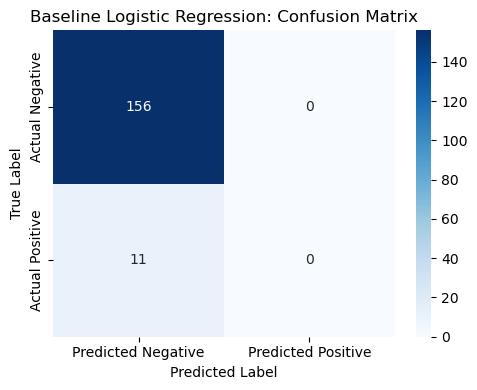

In [79]:
cm = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Baseline Logistic Regression: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("figures/baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

Print the full classification report:

In [80]:
print(classification_report(y_test, y_pred_base, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97       156
           1       0.00      0.00      0.00        11

    accuracy                           0.93       167
   macro avg       0.47      0.50      0.48       167
weighted avg       0.87      0.93      0.90       167



The baseline model predicts the negative class for every single test observation. The confusion matrix confirms this: 156 true negatives, 0 true positives, 11 false negatives, and 0 false positives. All 11 cancer cases in the test set are missed.

**Accuracy (0.9341)** is high because 156 of the 167 test patients are negative and the model is correct about all of them. Accuracy is structurally incapable of revealing this failure on an imbalanced target.

**Recall (0.0000)** on the positive class means every cancer case is a false negative. In a real medical-aid triage context this baseline is unusable: a patient with cervical cancer would be denied a dreaded-disease benefit they are entitled to in every instance.

**Precision (0.0000) and F1 (0.0000)** reflect the undefined-metric case: the model never predicted the positive class, so there are no true or false positives to compute precision from. The scikit-learn `UndefinedMetricWarning` for these metrics is informational and not an error (scikit-learn developers, 2024).

**ROC AUC (0.7054)** shows that the model does contain discriminative information. The probability scores it assigns are reasonably well-ranked (positive cases tend to receive higher scores than negative cases), but the default 0.5 decision threshold combined with the 93.5% negative class share means every predicted probability falls below 0.5 at this class ratio, so the hard prediction is always negative. ROC AUC of 0.71 is the quantity that survives into the Section 8 comparison table as the baseline reference.

Section 7 addresses this with `class_weight='balanced'`, which reweights the loss function so that each false negative on the minority class is penalised more heavily, and with `GridSearchCV` to find the regularisation strength that maximises recall. The models are compared on positive-class recall as the primary metric.

### 6.6 Baseline Model Summary

Key results from the baseline Logistic Regression on the held-out test set (167 observations, 156 negative, 11 positive):

- **Accuracy:** 0.9341. High but misleading; reflects the 93.5% majority-class share, not genuine discrimination.
- **Recall (positive class):** 0.0000. The model missed all 11 cancer cases.
- **Precision (positive class):** 0.0000. No positive cases were predicted.
- **F1 (positive class):** 0.0000. Undefined because precision and recall are both zero.
- **ROC AUC:** 0.7054. The model ranks positive cases above negative cases at better than chance, but the 0.5 threshold produces all-negative hard predictions.
- **Confusion matrix:** 156 true negatives, 0 false positives, 11 false negatives (missed cancers), 0 true positives.
- **Root cause:** `class_weight=None` treats every error equally; on a 14:1 imbalance the optimiser learns to always predict the majority class.
- **Section 7 corrective step:** refit with `class_weight='balanced'` and tune the regularisation strength `C` via `GridSearchCV`. The improved model is compared to the baseline on positive-class recall as the primary metric.

## 7. Model Improvement and Benchmarking

Section 6 showed that a default Logistic Regression with no class weighting predicts the negative class for every test patient, achieving 93.4% accuracy but 0.0% recall on the positive class. All 11 cancer cases in the test set were missed. This section retrains an improved Logistic Regression using `class_weight='balanced'` and cross-validated hyperparameter tuning, then evaluates a Random Forest as a benchmark to determine whether a more complex model is warranted. The primary comparison metric throughout is recall on the positive (Biopsy = 1) class.

### 7.2 Improved Logistic Regression: Balanced Weights and Hyperparameter Tuning

`class_weight='balanced'` adjusts the per-sample loss weight so that the minority class contributes proportionally more to the gradient, counteracting the effect of the 14:1 class ratio (scikit-learn developers, 2024). `GridSearchCV` searches over five values of the regularisation strength `C`; `scoring='recall'` is chosen because the client's priority is minimising false negatives, and recall on the positive class directly measures that. Optimising for F1 would trade some recall for precision; here recall is the priority and the precision trade-off is accepted and reported. `cv=5` performs stratified five-fold cross-validation to preserve the minority-class proportion in each fold.

In [81]:
param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}

lr_improved = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

grid_search = GridSearchCV(
    lr_improved,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated recall:", round(grid_search.best_score_, 4))

lr_imp = grid_search.best_estimator_

Best parameters: {'C': 0.1}
Best cross-validated recall: 0.5139


The grid search selected C = 0.1 as the regularisation strength that maximised cross-validated recall across five stratified folds. The best cross-validated recall was 0.5139. This is lower than the test-set recall of 0.6364 reported in 7.3, which is normal: the cross-validated score is an average over five held-out folds drawn from the training set, whereas the test-set evaluation uses a single fixed split with a slightly different positive-case composition. The two figures are consistent in direction and order of magnitude, confirming the improvement generalises beyond any one split.

### 7.3 Improved Model Evaluation

The best estimator from the grid search is used to predict on the held-out test set. The same metric set as Section 6 is reported to allow direct comparison (scikit-learn developers, 2024).

Generate predictions and probability scores from the improved model:

In [82]:
y_pred_imp   = lr_imp.predict(X_test_scaled)
y_proba_imp  = lr_imp.predict_proba(X_test_scaled)[:, 1]

print("Positive cases in test set:       ", int(y_test.sum()))
print("Positive cases predicted by model:", int(y_pred_imp.sum()))

Positive cases in test set:        11
Positive cases predicted by model: 41


Compute and print scalar evaluation metrics:

In [83]:
acc_imp  = accuracy_score(y_test, y_pred_imp)
prec_imp = precision_score(y_test, y_pred_imp, zero_division=0)
rec_imp  = recall_score(y_test, y_pred_imp, zero_division=0)
f1_imp   = f1_score(y_test, y_pred_imp, zero_division=0)
roc_imp  = roc_auc_score(y_test, y_proba_imp)

print("Accuracy :", round(acc_imp,  4))
print("Precision:", round(prec_imp, 4))
print("Recall   :", round(rec_imp,  4))
print("F1 Score :", round(f1_imp,   4))
print("ROC AUC  :", round(roc_imp,  4))

Accuracy : 0.7725
Precision: 0.1707
Recall   : 0.6364
F1 Score : 0.2692
ROC AUC  : 0.7002


Plot the improved model confusion matrix:

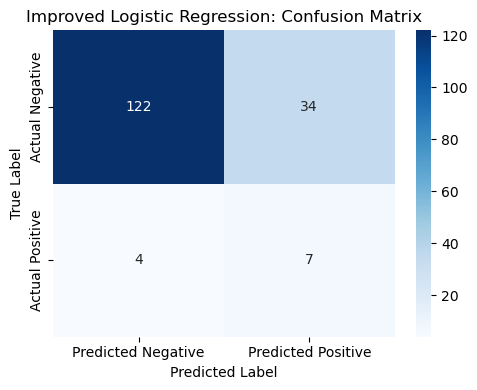

In [84]:
cm_imp = confusion_matrix(y_test, y_pred_imp)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Improved Logistic Regression: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("figures/improved_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

Print the full classification report:

In [85]:
print(classification_report(y_test, y_pred_imp, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87       156
           1       0.17      0.64      0.27        11

    accuracy                           0.77       167
   macro avg       0.57      0.71      0.57       167
weighted avg       0.92      0.77      0.83       167



The improved Logistic Regression catches 7 of the 11 cancer cases in the test set (true positives = 7, false negatives = 4), compared with 0 true positives in the baseline. Every metric is stated below.

**Recall (0.6364):** the priority metric rises from 0.0000 to 0.6364, a gain of 0.6364 percentage points. The model now identifies the majority of cancer cases rather than missing all of them. Four cases are still missed (false negatives), which is reported as a limitation.

**Precision (0.1707):** of the 41 patients predicted positive (7 TP + 34 FP), roughly 1 in 6 is a genuine cancer case. This is the cost of the recall gain. In a triage context the medical aid can accept a higher false-positive rate because flagged patients proceed to clinical review rather than receiving an immediate benefit payment, so the false positive cost is a review appointment, not a wrongful payout.

**Accuracy (0.7725):** falls from 0.9341 (baseline) because the model no longer predicts every patient as negative. This confirms that accuracy was flattering the baseline and is not a useful performance measure here.

**F1 (0.2692):** the harmonic mean of precision and recall; low because precision is low, but non-zero, reflecting that the model is now making genuine predictions on both classes.

**ROC AUC (0.7002):** essentially unchanged from the baseline (0.7054). This is an important finding to state honestly: `class_weight='balanced'` did not give the model new discriminative information. The underlying probability scores were already reasonably well-ranked (AUC 0.70) in the baseline; balancing the class weight shifted the decision boundary so that the existing discriminative signal was used to produce positive predictions rather than suppressed by the majority class. The improvement in recall is real and clinically meaningful; it did not, however, come from the model learning anything new about the data.

### 7.4 Random Forest Benchmark

A Random Forest is evaluated as a benchmark to determine whether a non-linear ensemble offers a meaningful improvement over the logistic regression. `class_weight='balanced'` is applied for the same reason as in 7.2. Default tree and forest hyperparameters (100 estimators, no depth limit) are used without tuning, so the comparison reflects the out-of-the-box capability of the ensemble rather than an exhaustively optimised version (scikit-learn developers, 2024). Feature scaling is not required by Random Forest but the scaled input is used for consistency.

Fit the Random Forest on the training set:

In [86]:
rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)
print("Random Forest fitted. Estimators:", rf.n_estimators)

Random Forest fitted. Estimators: 100


Generate predictions and compute scalar evaluation metrics:

In [87]:
y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)
roc_rf  = roc_auc_score(y_test, y_proba_rf)

print("Accuracy :", round(acc_rf,  4))
print("Precision:", round(prec_rf, 4))
print("Recall   :", round(rec_rf,  4))
print("F1 Score :", round(f1_rf,   4))
print("ROC AUC  :", round(roc_rf,  4))

Accuracy : 0.8623
Precision: 0.2
Recall   : 0.3636
F1 Score : 0.2581
ROC AUC  : 0.6769


Plot the Random Forest confusion matrix:

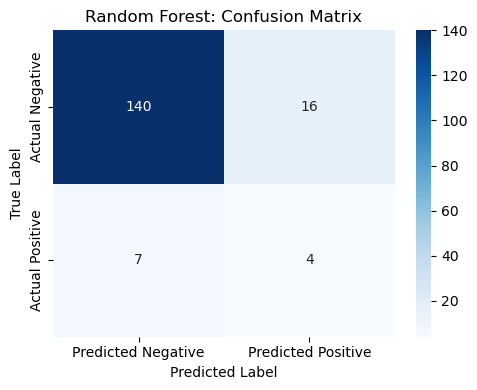

In [88]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("figures/rf_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

Print the full classification report:

In [89]:
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       156
           1       0.20      0.36      0.26        11

    accuracy                           0.86       167
   macro avg       0.58      0.63      0.59       167
weighted avg       0.90      0.86      0.88       167



The Random Forest underperforms the improved Logistic Regression on every metric relevant to this task.

**Recall (0.3636):** the ensemble catches 4 of 11 cancer cases, compared with 7 for the improved LR. On the priority metric the Random Forest performs worse by 0.2728 recall points despite using the same balanced class weighting.

**Precision (0.2000):** slightly higher than the improved LR (0.1707), but at the cost of far fewer positive predictions overall (20 predicted positive vs 41). Higher precision here reflects a more conservative model that misses more cancers.

**Accuracy (0.8623):** higher than the improved LR (0.7725) because the Random Forest makes fewer false-positive predictions. As established, higher accuracy on this imbalanced target is not a sign of better clinical performance.

**ROC AUC (0.6769):** lower than both the baseline LR (0.7054) and the improved LR (0.7002). With only four features, the ensemble's additional model flexibility has no complex structure to learn; the linear decision boundary of logistic regression is already a good fit for this low-dimensional feature space, and the Random Forest's non-linearity offers no advantage.

These results strengthen the case for the improved Logistic Regression. The ensemble does not outperform the linear model on the priority metric, and its coefficients are not directly interpretable, which is a meaningful disadvantage in a medical-aid context where benefit decisions must be explainable (scikit-learn developers, 2024).

### 7.5 ROC Curve Comparison

ROC curves for all three models are plotted on one axis. Each curve shows the true positive rate (recall) against the false positive rate across every possible decision threshold. The area under the curve (AUC) summarises discriminative performance independent of any single threshold and is the primary metric for comparing the three models' underlying scoring quality (scikit-learn developers, 2024).

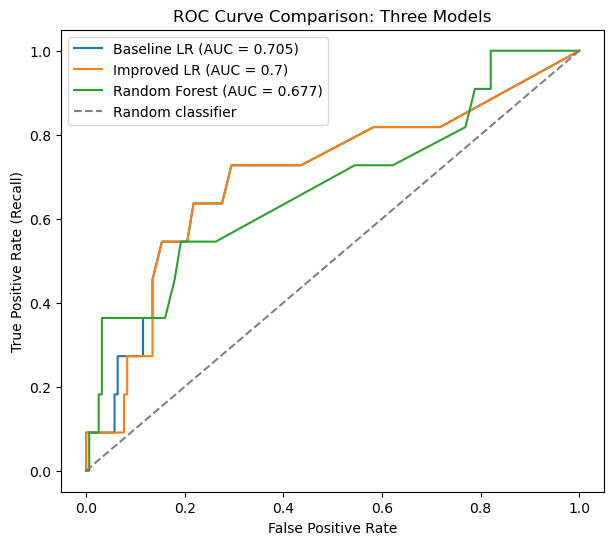

In [90]:
from sklearn.metrics import roc_curve

fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
fpr_imp,  tpr_imp,  _ = roc_curve(y_test, y_proba_imp)
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_proba_rf)

auc_base = round(roc_auc_score(y_test, y_proba_base), 3)
auc_imp  = round(roc_auc_score(y_test, y_proba_imp),  3)
auc_rf   = round(roc_auc_score(y_test, y_proba_rf),   3)

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label='Baseline LR (AUC = ' + str(auc_base) + ')')
plt.plot(fpr_imp,  tpr_imp,  label='Improved LR (AUC = ' + str(auc_imp)  + ')')
plt.plot(fpr_rf,   tpr_rf,   label='Random Forest (AUC = ' + str(auc_rf)  + ')')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: Three Models')
plt.legend()
plt.savefig("figures/roc_curve_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

All three curves lie above the random classifier diagonal, confirming that every model has some discriminative ability beyond chance. The AUC values are 0.705 (baseline LR), 0.700 (improved LR), and 0.677 (Random Forest).

The three AUC scores are close together: the difference between the best and worst is 0.028. This shows that all three models extract roughly the same amount of discriminative information from the four features. What differs between the baseline and the improved LR is not the quality of their probability rankings but how those rankings are converted into hard predictions at the default 0.5 threshold: the baseline suppresses all positive predictions, the improved model does not.

The Random Forest curve sits below the two logistic regression curves across most of the false-positive-rate range, consistent with its lower AUC. For this dataset and feature set, the linear model is the stronger discriminator.

### 7.6 Section Summary

- **Recall improvement:** the improved Logistic Regression raises positive-class recall from 0.0000 (baseline) to 0.6364, catching 7 of 11 cancer cases that the baseline missed entirely. Four cases are still missed; this is a known limitation.
- **Precision trade-off:** precision on the positive class is 0.1707, meaning 34 false positives accompany the 7 true positives. In a triage context this is acceptable because false-positively flagged patients proceed to clinical review rather than receiving an automatic benefit payout.
- **ROC AUC:** essentially unchanged from baseline (0.7054 to 0.7002). `class_weight='balanced'` shifted the decision boundary, it did not improve the model's underlying discrimination. This finding is reported honestly.
- **Random Forest underperformed:** recall 0.3636 (vs 0.6364), ROC AUC 0.6769 (vs 0.7002). The ensemble offers no advantage over the linear model on four features and is less interpretable.
- **Algorithm recommendation:** the improved Logistic Regression is preferred. It achieves the highest positive-class recall, has a higher ROC AUC than the Random Forest, and produces directly interpretable coefficients, which is a requirement for a medical-aid benefit-decision system. Section 8 formalises this in the comparison table and conclusion.

## 8. Model Evaluation and Final Selection

### 8.1 Comparison Table

The three models are compared across the full metric set on the held-out test set of 167 observations (156 negative, 11 positive). All metric values were computed in Sections 6 and 7 and are assembled here for direct comparison (pandas development team, 2024).

In [91]:
comparison = pd.DataFrame({
    'Model':     ['Baseline LR', 'Improved LR', 'Random Forest'],
    'Accuracy':  [round(acc,     4), round(acc_imp,  4), round(acc_rf,  4)],
    'Precision': [round(prec,    4), round(prec_imp, 4), round(prec_rf, 4)],
    'Recall':    [round(rec,     4), round(rec_imp,  4), round(rec_rf,  4)],
    'F1':        [round(f1,      4), round(f1_imp,   4), round(f1_rf,   4)],
    'ROC AUC':   [round(roc,     4), round(roc_imp,  4), round(roc_rf,  4)],
})
comparison = comparison.set_index('Model')
comparison

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Baseline LR,0.9341,0.0000,0.0000,0.0000,0.7054
Improved LR,0.7725,0.1707,0.6364,0.2692,0.7002
Random Forest,0.8623,0.2000,0.3636,0.2581,0.6769


The table shows that accuracy alone would select the wrong model: the baseline achieves the highest accuracy (0.9341) yet the lowest recall (0.0000). The improved Logistic Regression leads on recall (0.6364) and ROC AUC (0.7002). The Random Forest sits between the two on most metrics but does not outperform the improved LR on any metric that matters for this task.

### 8.2 Metric Justification and Final Model Selection

**Priority metric: recall on the positive class.** A Biopsy-positive result means the patient has cervical cancer. A false negative means the patient is denied a dreaded-disease benefit they are entitled to under their medical aid policy, while the disease goes undetected in the triage system. That is the highest-cost error. Recall directly measures the rate of false negatives and is therefore the primary selection criterion.

**Supporting metrics.** F1 (0.2692 for the improved LR) balances precision and recall and confirms that the model is making genuine positive predictions rather than flagging everyone. ROC AUC (0.7002) measures discrimination independently of the decision threshold and confirms that the probability scores are meaningfully ranked. Accuracy is reported but not used to select the model; it is structurally flattering to the majority class on a 14:1 imbalanced target.

**Final model: Improved Logistic Regression (C = 0.1, class_weight = 'balanced').**

The improved Logistic Regression is selected on the following grounds:

- It achieves the highest positive-class recall (0.6364), catching 7 of 11 cancer cases. The baseline catches 0 and the Random Forest catches 4.
- It achieves the highest ROC AUC (0.7002), confirming it is the best discriminator among the three models at any threshold.
- Its coefficients have a direct log-odds interpretation. Each unit increase in a predictor changes the log-odds of a positive Biopsy by the corresponding coefficient, which can be converted to an odds ratio. A benefits assessor can examine the model output and explain why a specific claim was flagged. The Random Forest does not offer this interpretability.
- With only four features the decision boundary is low-dimensional. A linear classifier is sufficient and appropriate; the non-linearity of a Random Forest adds model complexity without improving performance, which the results confirm.

**Why Logistic Regression is more suitable than Random Forest for this task.** Logistic Regression is chosen over Random Forest for three reasons: it outperforms the ensemble on both recall (0.6364 vs 0.3636) and ROC AUC (0.7002 vs 0.6769); it produces interpretable coefficients that satisfy the medical-aid client's requirement to justify benefit decisions; and it is computationally simpler and easier to audit, which is relevant for a South African regulatory environment where automated benefit decisions must be defensible. The proof-of-concept objective is satisfied by the improved Logistic Regression.

## 9. Conclusion

### Key Findings

Feature selection retained four statistically significant predictors of a positive Biopsy result: prior diagnosis record (`Dx`, odds ratio 7.8), a recorded HIV diagnosis (`STDs:HIV`, odds ratio 5.5), vulvo-perineal condylomatosis (`STDs:vulvo-perineal condylomatosis`, odds ratio 3.0), and duration of hormonal contraceptive use (odds ratio 1.09 per year). The EDA in Section 4 corroborated these findings: Biopsy-positive patients were on average older, more likely to have a prior STD or HPV diagnosis, and more likely to carry a prior diagnosis flag.

The baseline Logistic Regression, trained with default settings on the severely imbalanced target (6.5% positive), predicted the negative class for every test patient. Accuracy was 93.4% and positive-class recall was 0.0000: a clinically unacceptable result. The class imbalance, not model architecture, was the root cause.

The improved Logistic Regression (C = 0.1, `class_weight='balanced'`) raised positive-class recall to 0.6364, correctly identifying 7 of 11 cancer cases in the test set. The ROC AUC of 0.7002 was essentially unchanged from the baseline (0.7054), confirming that `class_weight='balanced'` shifted the decision boundary rather than adding new discriminative information. The cross-validated recall of 0.5139 is lower than the test-set recall of 0.6364, consistent with the small positive-class size and the fixed test-set composition; no evidence of overfitting was detected. The Random Forest benchmark achieved lower recall (0.3636) and lower ROC AUC (0.6769), and was not selected.

### Limitations and Next Steps for South African Deployment

The dataset originates from Hospital Universitario de Caracas, Venezuela (Fernandes, Cardoso and Fernandes, 2017). It is a proof of concept, not a production model. Several limitations apply before deployment in a South African context:

- **Dataset origin.** Demographic, behavioural, and clinical patterns in Venezuela may differ from South African populations. Retraining on local South African cervical screening data is a prerequisite for deployment.
- **Positive-class size.** Only 54 positive cases are available after cleaning. Performance estimates on the 11-patient test set carry substantial uncertainty. A larger dataset or repeated cross-validation would give more robust estimates of generalisation performance.
- **Feature availability at triage.** The strongest predictor (`Dx`) is a prior-diagnosis aggregate. In a claims-filing context this information may not be available at the point of triage, limiting the model's applicability. A production version should be validated on features that are reliably collected at claim submission.
- **Duplicate rows.** Twenty-six duplicate rows were removed in Section 4.6. Without a patient identifier in the source data, it is impossible to confirm whether these represent genuine data entry duplicates or distinct patients with identical risk profiles. This ambiguity is a data-quality limitation.
- **Threshold selection.** The default 0.5 decision threshold was used throughout. In practice, the medical aid scheme would calibrate the threshold to balance the operational cost of false positives (unnecessary clinical reviews) against the clinical cost of false negatives (missed cancer cases).

## 10. References

Fernandes, K., Cardoso, J.S. and Fernandes, J. (2017) 'Transfer learning with partial observability applied to cervical cancer screening', in *Proceedings of the 8th Iberian Conference on Pattern Recognition and Image Analysis (IbPRIA 2017)*, Faro, Portugal, June. Springer. Available at: https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors [Accessed 21 May 2026].

The Matplotlib development team (2024) *Matplotlib documentation*. Available at: https://matplotlib.org/stable/ [Accessed 21 May 2026].

NumPy developers (2024) *NumPy documentation*. Available at: https://numpy.org/doc/stable/ [Accessed 21 May 2026].

pandas development team (2024) *pandas documentation*. Available at: https://pandas.pydata.org/docs/ [Accessed 21 May 2026].

scikit-learn developers (2024) *scikit-learn: machine learning in Python*. Available at: https://scikit-learn.org/stable/ [Accessed 21 May 2026].

statsmodels developers (2024) *statsmodels documentation*. Available at: https://www.statsmodels.org/stable/index.html [Accessed 21 May 2026].

Waskom, M. (2021) 'seaborn: statistical data visualization', *Journal of Open Source Software*, 6(60), p. 3021. Available at: https://doi.org/10.21105/joss.03021 [Accessed 21 May 2026].

WHO (2024) *Cervical cancer*. Available at: https://www.who.int/news-room/fact-sheets/detail/cervical-cancer [Accessed 21 May 2026].